In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install geoip2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 6.1 MB/s eta 0:00:00


In [ ]:
import community as community_louvain
import heapq
import geoip2.database
import random
from collections import defaultdict
from math import radians, sin, cos, sqrt, atan2
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from tabulate import tabulate  # Ensure you have the 'tabulate' library installed
from collections import deque
import geoip2.webservice
import numpy as np
import csv
from sklearn.metrics import silhouette_score
from sklearn.cluster import SpectralClustering
import pandas as pd
from collections import deque
import community as community_louvain
import math

5000 nodes

Now adding node to clustered graph
Initial cluster: {}
Cluster 1 split into 1 and 2 successfully.
Cluster 2 split into 2 and 3 successfully.
Cluster 1 split into 1 and 4 successfully.
Cluster 3 split into 3 and 5 successfully.
Cluster 2 split into 2 and 6 successfully.
Cluster 5 split into 5 and 7 successfully.
Cluster 1 split into 1 and 8 successfully.
Cluster 4 split into 4 and 9 successfully.
2000 number of nodes done
Cluster 8 split into 8 and 10 successfully.
Cluster 8 split into 8 and 11 successfully.
Cluster 5 split into 5 and 12 successfully.
Cluster 7 split into 7 and 13 successfully.
Cluster 4 split into 4 and 14 successfully.
Cluster 6 split into 6 and 15 successfully.
Cluster 2 split into 2 and 16 successfully.
Cluster 5 split into 5 and 17 successfully.
Cluster 15 split into 15 and 18 successfully.
Error in getting location
Error in getting location
Cluster 2 split into 2 and 19 successfully.
Cluster 13 split into 13 and 20 successfully.
4000 number of nodes done
Cluster 1

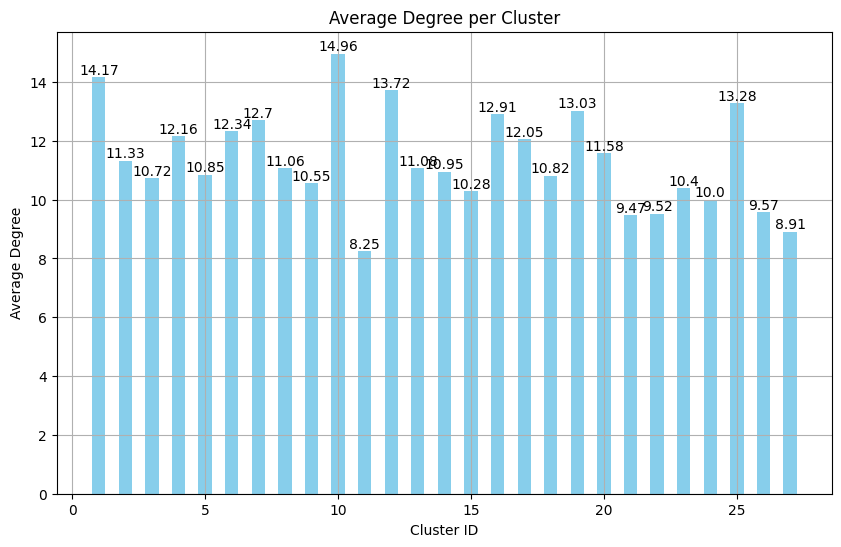

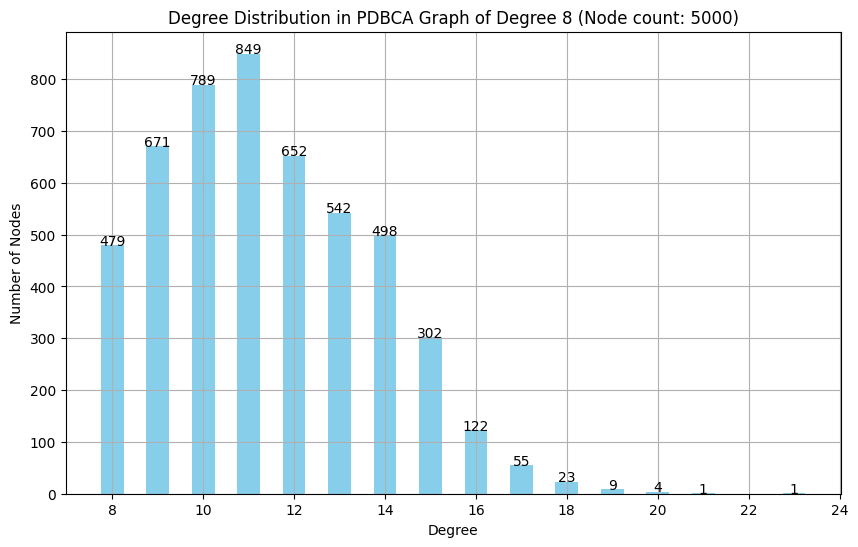

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [5000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)





#10000 Nodes


Now adding node to clustered graph
Initial cluster: {}
Cluster 1 split into 1 and 2 successfully.
Cluster 1 split into 1 and 3 successfully.
Cluster 2 split into 2 and 4 successfully.
Cluster 1 split into 1 and 5 successfully.
Cluster 3 split into 3 and 6 successfully.
Cluster 2 split into 2 and 7 successfully.
Cluster 5 split into 5 and 8 successfully.
Cluster 2 split into 2 and 9 successfully.
2000 number of nodes done
Cluster 5 split into 5 and 10 successfully.
Cluster 4 split into 4 and 11 successfully.
Cluster 3 split into 3 and 12 successfully.
Cluster 5 split into 5 and 13 successfully.
Cluster 2 split into 2 and 14 successfully.
Cluster 5 split into 5 and 15 successfully.
Cluster 7 split into 7 and 16 successfully.
Cluster 12 split into 12 and 17 successfully.
Cluster 7 split into 7 and 18 successfully.
Cluster 7 split into 7 and 19 successfully.
Cluster 7 split into 7 and 20 successfully.
Cluster 7 split into 7 and 21 successfully.
Cluster 7 split into 7 and 22 successfully.
C

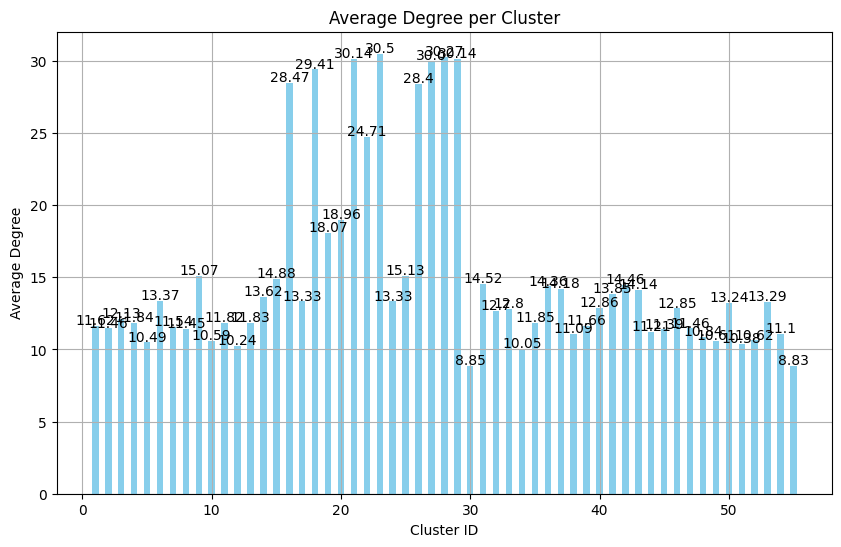

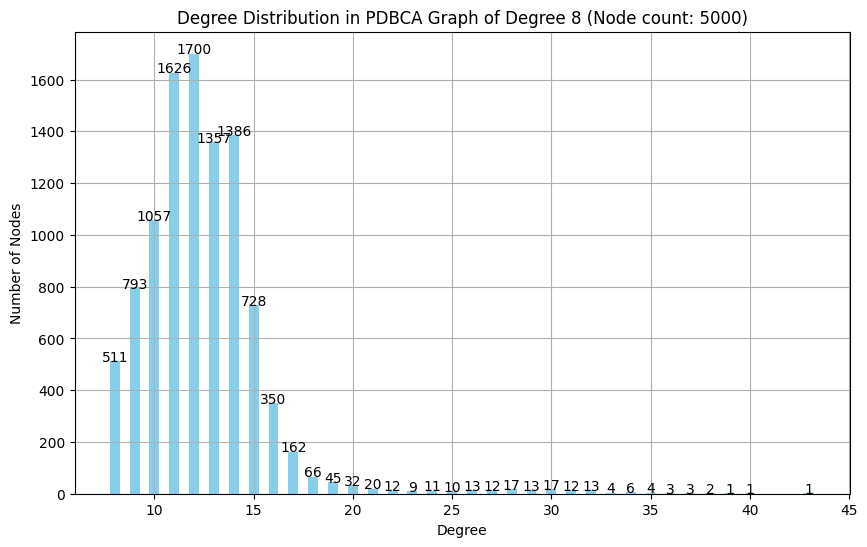

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [10000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)





#15000 nodes


Now adding node to clustered graph
Initial cluster: {}
Cluster 1 split into 1 and 2 successfully.
Cluster 2 split into 2 and 3 successfully.
Cluster 1 split into 1 and 4 successfully.
Error in getting location
Cluster 3 split into 3 and 5 successfully.
Cluster 1 split into 1 and 6 successfully.
Cluster 2 split into 2 and 7 successfully.
Cluster 1 split into 1 and 8 successfully.
Cluster 4 split into 4 and 9 successfully.
Cluster 2 split into 2 and 10 successfully.
2000 number of nodes done
Cluster 3 split into 3 and 11 successfully.
Cluster 5 split into 5 and 12 successfully.
Cluster 1 split into 1 and 13 successfully.
Cluster 5 split into 5 and 14 successfully.
Cluster 1 split into 1 and 15 successfully.
Cluster 4 split into 4 and 16 successfully.
Cluster 1 split into 1 and 17 successfully.
Cluster 5 split into 5 and 18 successfully.
Cluster 1 split into 1 and 19 successfully.
Cluster 3 split into 3 and 20 successfully.
Cluster 1 split into 1 and 21 successfully.
Cluster 1 split into 

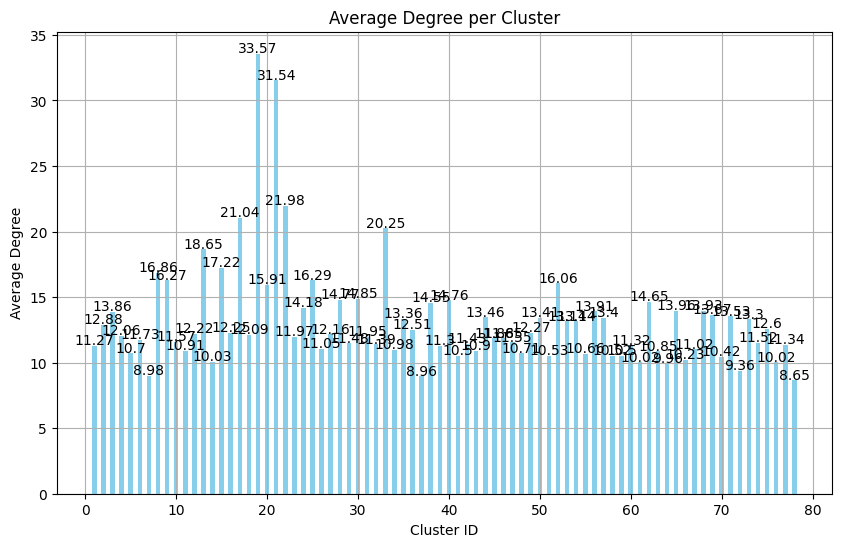

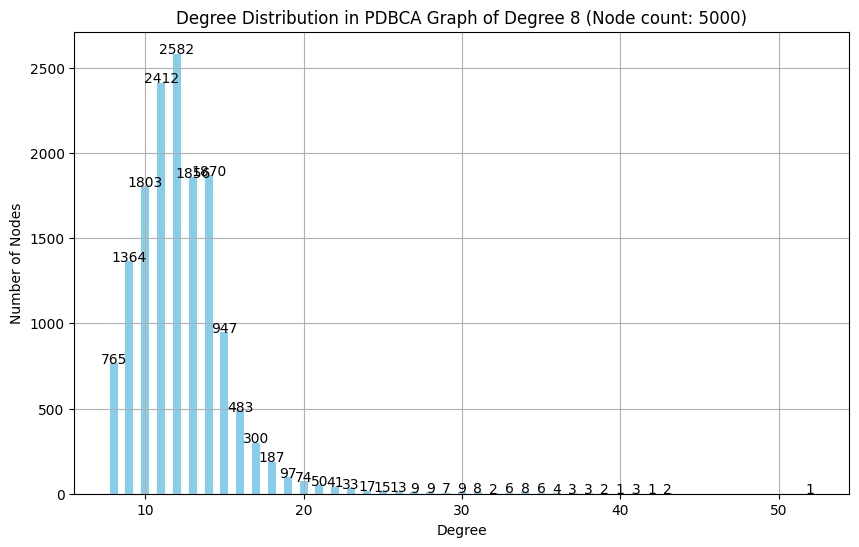

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [15000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)





20000 nodes

Now adding node to clustered graph
Initial cluster: {}
Error in getting location
Cluster 1 split into 1 and 2 successfully.
Error in getting location
Cluster 1 split into 1 and 3 successfully.
Cluster 2 split into 2 and 4 successfully.
Cluster 1 split into 1 and 5 successfully.
Cluster 4 split into 4 and 6 successfully.
Cluster 4 split into 4 and 7 successfully.
Cluster 4 split into 4 and 8 successfully.
Cluster 3 split into 3 and 9 successfully.
Cluster 4 split into 4 and 10 successfully.
Cluster 4 split into 4 and 11 successfully.
Cluster 4 split into 4 and 12 successfully.
Cluster 4 split into 4 and 13 successfully.
Error in getting location
Cluster 1 split into 1 and 14 successfully.
2000 number of nodes done
Cluster 5 split into 5 and 15 successfully.
Cluster 3 split into 3 and 16 successfully.
Cluster 4 split into 4 and 17 successfully.
Cluster 2 split into 2 and 18 successfully.
Cluster 1 split into 1 and 19 successfully.
Error in getting location
Cluster 9 split into 9 and 20 s

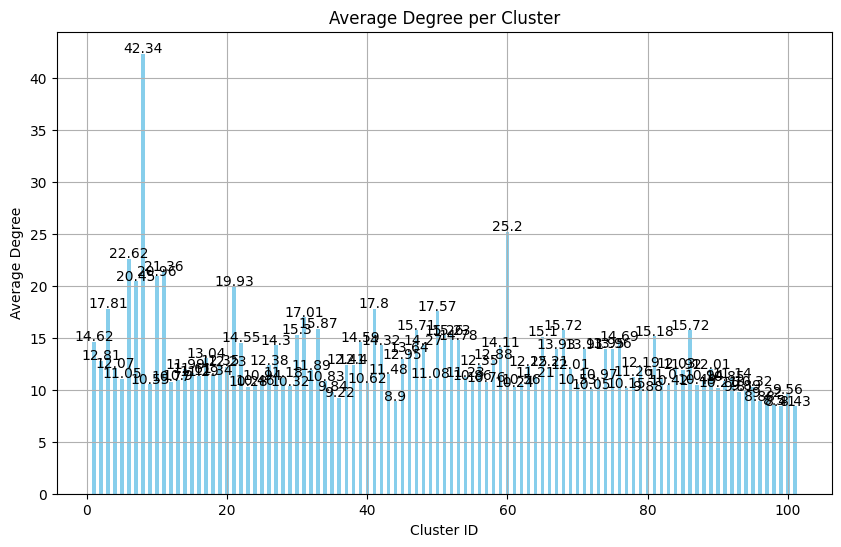

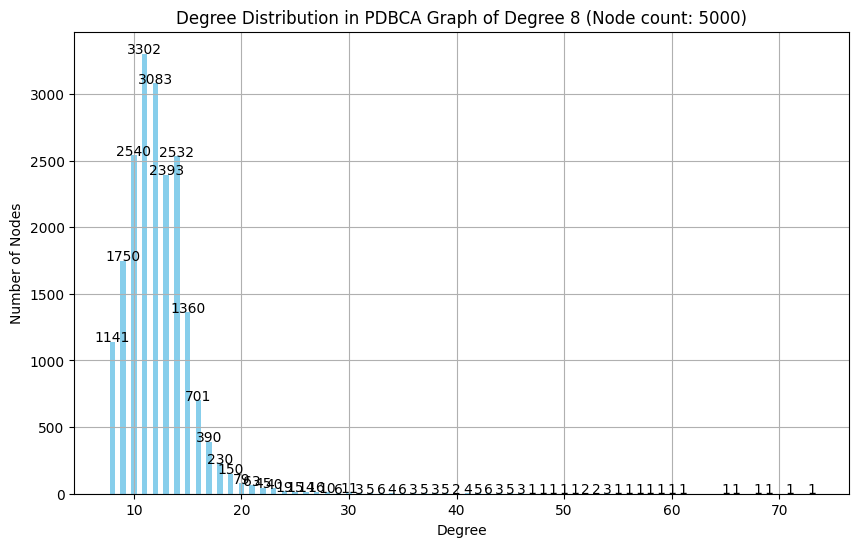

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [20000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)





#30000 Nodes


Now adding node to clustered graph
Initial cluster: {}
Cluster 1 split into 1 and 2 successfully.
Cluster 1 split into 1 and 3 successfully.
Cluster 2 split into 2 and 4 successfully.
Cluster 1 split into 1 and 5 successfully.
Cluster 4 split into 4 and 6 successfully.
Error in getting location
Cluster 3 split into 3 and 7 successfully.
Cluster 4 split into 4 and 8 successfully.
Cluster 3 split into 3 and 9 successfully.
Cluster 5 split into 5 and 10 successfully.
2000 number of nodes done
Cluster 2 split into 2 and 11 successfully.
Cluster 3 split into 3 and 12 successfully.
Cluster 1 split into 1 and 13 successfully.
Cluster 2 split into 2 and 14 successfully.
Cluster 3 split into 3 and 15 successfully.
Cluster 5 split into 5 and 16 successfully.
Cluster 3 split into 3 and 17 successfully.
Cluster 8 split into 8 and 18 successfully.
Error in getting location
Error in getting location
Cluster 8 split into 8 and 19 successfully.
Cluster 5 split into 5 and 20 successfully.
Cluster 10 sp

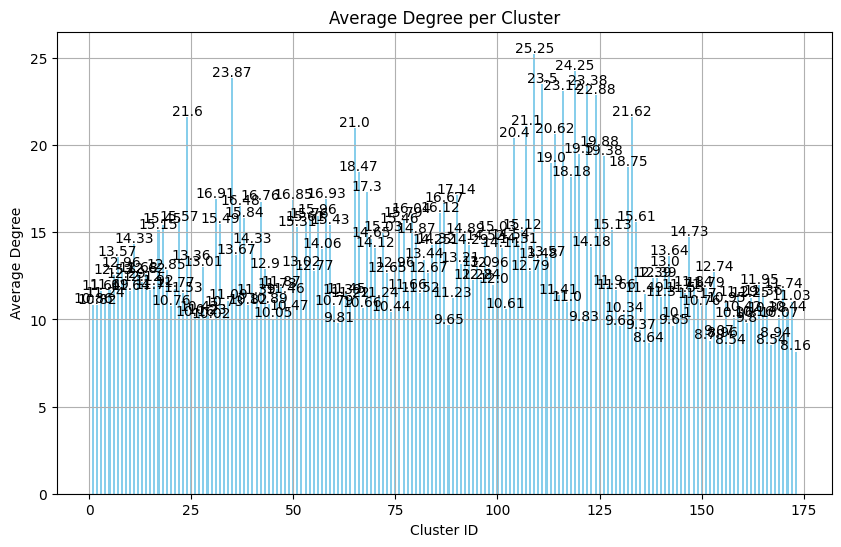

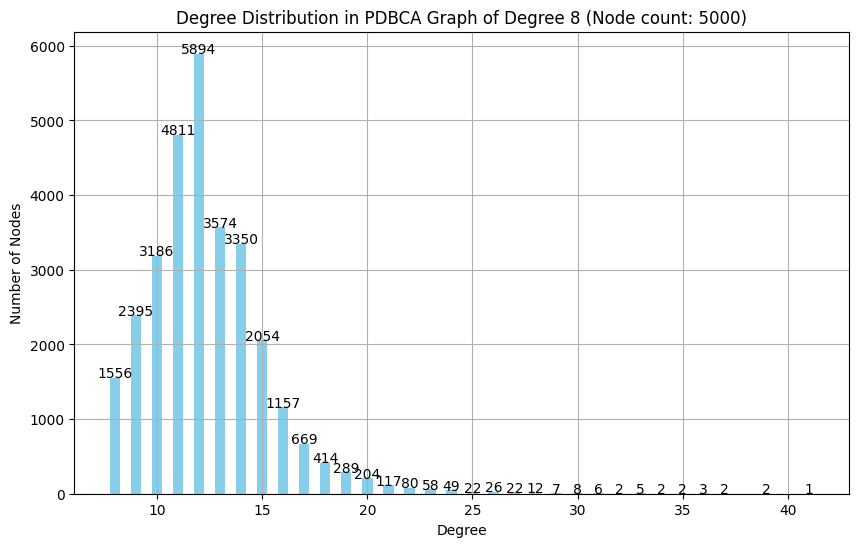

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [30000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)








#50000 Nodes

Now adding node to clustered graph
Initial cluster: {}
Cluster 1 split into 1 and 2 successfully.
Error in getting location
Cluster 2 split into 2 and 3 successfully.
Cluster 1 split into 1 and 4 successfully.
Error in getting location
Cluster 3 split into 3 and 5 successfully.
Cluster 2 split into 2 and 6 successfully.
Cluster 4 split into 4 and 7 successfully.
Cluster 1 split into 1 and 8 successfully.
Cluster 3 split into 3 and 9 successfully.
2000 number of nodes done
Cluster 3 split into 3 and 10 successfully.
Cluster 1 split into 1 and 11 successfully.
Cluster 3 split into 3 and 12 successfully.
Cluster 2 split into 2 and 13 successfully.
Cluster 7 split into 7 and 14 successfully.
Cluster 4 split into 4 and 15 successfully.
Cluster 2 split into 2 and 16 successfully.
Cluster 12 split into 12 and 17 successfully.
Cluster 2 split into 2 and 18 successfully.
Cluster 12 split into 12 and 19 successfully.
Cluster 9 split into 9 and 20 successfully.
Cluster 2 split into 2 and 21 succe

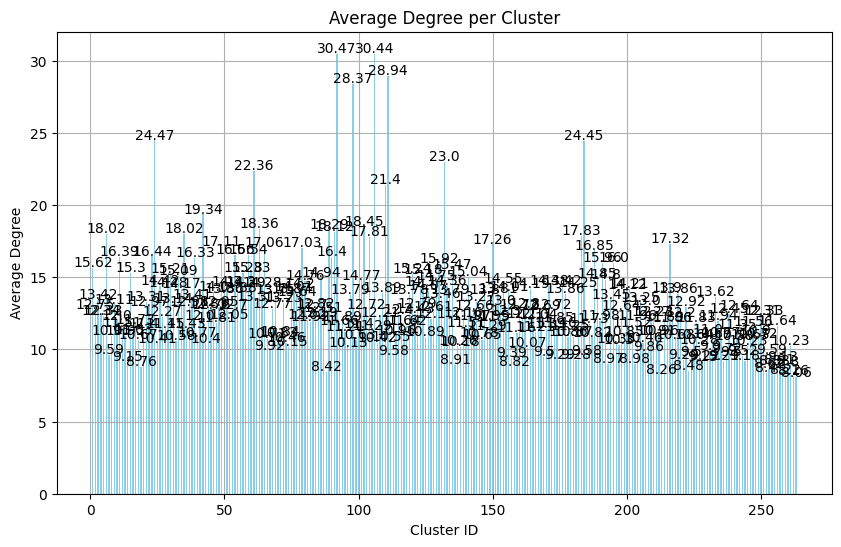

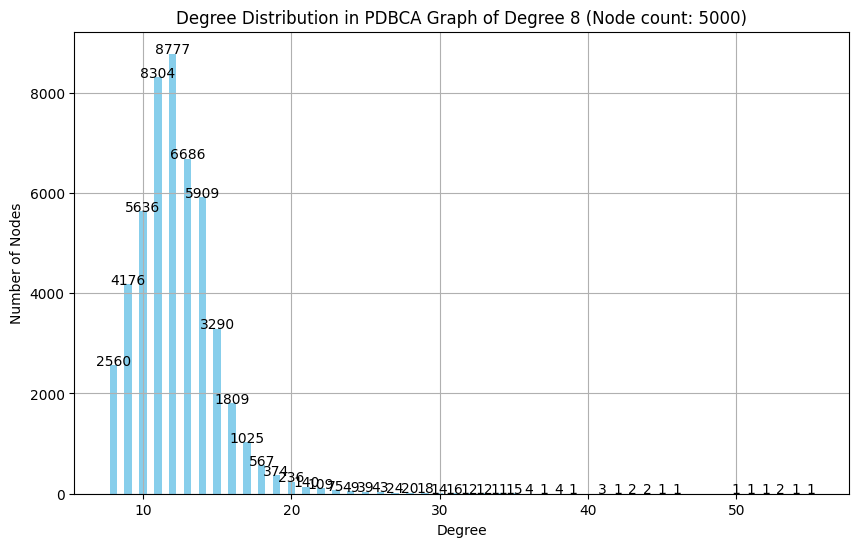

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering
import numpy as np
import os
import time

class IPAddressGraph:
    def __init__(self):
        # Neo4j Driver and Graph Initialization
        self.G = nx.Graph()  # NetworkX graph object to represent the graph
        # Message Forwarding Tracker
        self.total_messages_forwarded = 0
        self.reader = geoip2.database.Reader('/content/drive/MyDrive/P2p/GeoLite2-City.mmdb')
        # Variables for Spectral Clustering Process
        self.cluster_to_nodes = {}  # Dictionary to store node-to-cluster mapping
        #self.cluster_sizes = {}  # Dictionary to store sizes of each cluster
        self.cluster_done=0
        self.r_max=None
        # Lists to store results of different clustering iterations
        self.clusters_list = []  # Stores the number of clusters
        self.messages_forwarded_list = []  # Stores messages forwarded for each clustering
        self.cluster_centroids = {}
        self.cluster_cartesian_sums = {}
        self.cluster_sizes = {}
        # To store the valid graph (graph where all clusters have >= 8 nodes)
        self.previous_graph = None  # Stores the last valid graph

    def haversine(self, lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
        c = 2 * atan2(sqrt(a), sqrt(1 - a))
        r = 6371.0  # Earth radius in kilometers
        distance = r * c
        return distance

    def perform_spectral_clustering(self, G, num_clusters):
        adj_matrix = nx.to_numpy_array(G)
        spectral = SpectralClustering(n_clusters=num_clusters, affinity='precomputed', random_state=42)
        labels = spectral.fit_predict(adj_matrix)

        node_to_cluster = {node: labels[i] for i, node in enumerate(G.nodes())}
        return node_to_cluster  # Return node-to-cluster mapping








    def calculate_total_messages_forwarded(self):
        if not self.G.nodes:
            print("The graph doesn't contain any nodes.")
            return 0

        total_nodes = len(self.G.nodes)
        all_nodes = list(self.G.nodes)
        self.total_messages_forwarded = 0

        received_message = {node: False for node in all_nodes}
        event_queue = [(0, all_nodes[0], None)]  # Start from a random node

        while event_queue:
            current_time, current_node, sender = heapq.heappop(event_queue)

            if not received_message[current_node]:
                received_message[current_node] = True

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)
                        heapq.heappush(event_queue, (current_time + delay_ms, neighbor, current_node))
                        self.total_messages_forwarded += 1

        #print(f"Total messages forwarded: {self.total_messages_forwarded}")
        return self.total_messages_forwarded, total_nodes
    def visualize_graph_with_edges(self, removed_edges, restored_edges):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout

        # Draw all nodes
        nx.draw(self.G, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

        # Draw restored edges in green
        nx.draw_networkx_edges(self.G, pos, edgelist=restored_edges, edge_color='green', width=2, label="Restored Edges")

        # Draw removed edges in red (even if they are not in the graph, we show them as dashed lines)
        nx.draw_networkx_edges(self.G, pos, edgelist=removed_edges, edge_color='red', style='dashed', width=2, label="Removed Edges")

        # Display edge labels (distance)
        edge_labels = nx.get_edge_attributes(self.G, 'distance')
        nx.draw_networkx_edge_labels(self.G, pos, edge_labels=edge_labels)

        # Add legend
        plt.legend()
        plt.title("Graph Visualization After Clustering (Removed and Restored Edges)")
        plt.axis('off')
        plt.show()

    def visualize_clusters_after_clustering(self, node_to_cluster):
        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.G)  # Node layout
        cluster_colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

        # Draw nodes, coloring them by cluster
        for cluster_id in set(node_to_cluster.values()):
            cluster_nodes = [node for node in self.G.nodes() if node_to_cluster[node] == cluster_id]
            nx.draw_networkx_nodes(self.G, pos, nodelist=cluster_nodes,
                                   node_color=cluster_colors[cluster_id % len(cluster_colors)],
                                   label=f'Cluster {cluster_id}', node_size=500)

        # Draw edges
        nx.draw_networkx_edges(self.G, pos, edge_color='gray')
        nx.draw_networkx_labels(self.G, pos, font_size=10)

        plt.legend()
        plt.title("Graph Visualization of Nodes After Spectral Clustering")
        plt.axis('off')
        plt.show()
    def check_graph_connectivity(self):
        if nx.is_connected(self.G):
            #print("The graph is connected.")
            pass
        else:
            print("The graph is disconnected.")
            components = list(nx.connected_components(self.G))
            print(f"The graph has {len(components)} connected components.")

    def calculate_dynamic_delay(self, distance):
        return (distance / 1000) * 4  # Example delay formula


    def find_cluster_for_new_node(self, new_ip, cluster_to_nodes):
        """
        Find the cluster ID for the new node based on the average Haversine distance to nodes in each cluster.

        Args:
            new_ip (str): The new IP address (node) to connect to a cluster.
            node_to_cluster (dict): A dictionary mapping nodes to their respective cluster IDs.

        Returns:
            cluster_id (int): The ID of the cluster with the smallest average distance.
        """
        # Check if node_to_cluster is empty
        if not cluster_to_nodes:
            print("Error: cluster_to_nodes mapping is empty.")
            return None

        # Get the location of the new IP address
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None  # If location can't be found, return None

        best_cluster_id = None
        min_avg_distance = float('inf')

        # 1. Iterate directly over the clusters and their node lists
        for cluster_id, nodes in cluster_to_nodes.items():

            # 2. Optimized check: Skip clusters with fewer than 8 nodes instantly
            if len(nodes) < 8:
                continue

            total_distance = 0
            valid_nodes_count = 0

            # 3. Calculate distance only for nodes in this specific cluster
            for node in nodes:
                distance = self.get_distance(new_ip, node)
                if distance is not None:
                    total_distance += distance
                    valid_nodes_count += 1

            if valid_nodes_count > 0:
                avg_distance = total_distance / valid_nodes_count

                # 4. Update the best cluster without storing a separate list of tuples
                if avg_distance < min_avg_distance:
                    min_avg_distance = avg_distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid clusters found for IP: {new_ip}")

        return best_cluster_id

    def find_cluster_for_new_node(self, new_ip):
        """
        Assign new node to closest cluster based on centroid distance
        and update centroid after assignment.
        """

        cluster_centroids = ip_graph.cluster_centroids

        # Step 1: Check input
        if not cluster_centroids:
            print("Error: cluster_centroids is empty.")
            return None

        # Step 2: Get coordinates of new node
        new_location = self.get_location(new_ip)
        if not new_location:
            print(f"Error: Unable to find location for IP {new_ip}.")
            return None

        lat_p, lon_p = new_location

        best_cluster_id = None
        d_min = float('inf')

        # Step 3: Find closest centroid
        for cluster_id, (lat_c, lon_c) in cluster_centroids.items():

            # Optional constraint (keep if needed)
            nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
            if len(nodes) < 8:
                continue

            distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))

            if distance < d_min:
                d_min = distance
                best_cluster_id = cluster_id

        # Step 4: Fallback if all clusters skipped
        if best_cluster_id is None:
            for cluster_id, (lat_c, lon_c) in cluster_centroids.items():
                distance = self.get_distance_to_centroid(new_ip, (lat_c, lon_c))
                if distance < d_min:
                    d_min = distance
                    best_cluster_id = cluster_id

        if best_cluster_id is None:
            print(f"No valid cluster found for IP: {new_ip}")
            return None


        self.update_centroid_incremental(best_cluster_id, new_ip)



        return best_cluster_id



    def add_node_connect_cluster(self, ip, out_degree, cluster_to_nodes,alpha,beta,min_nodes):
        """
        Add a node to the graph and connect it to its nearest neighbors in the selected cluster.

        Args:
            ip (str): The IP address (node) to be added.
            out_degree (int): The number of nearest neighbors to connect to.
            node_to_cluster (dict): Dictionary mapping node IPs to cluster IDs.
        """
        start_time = time.time()
        last_interval_time = start_time
        #print("Count of nodes:",len(list(self.G.nodes)))
        if ip not in self.G.nodes:
           # print(f"Trying to get location for {ip}")
            location = self.get_location(ip)
           # print(f"Success in getting location")
            if location:
                self.G.add_node(ip, pos=location)
                #print(f"Added position {ip}")
                if self.cluster_done:
                    # Get the cluster ID for this node
                    #print(f"Adding node {ip} to clustered graph")
                    cluster_id = self.find_cluster_for_new_node(ip)
                    if cluster_id is None:
                        print("Cluster id not returned by function")
                        return  # If no suitable cluster found, return
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []
                    cluster_to_nodes[cluster_id].append(ip)
                    # Add the new node to the node_to_cluster mapping

                    #print(f"Node {ip} assigned to cluster {cluster_id}.")
                    this_cluster_nodes = cluster_to_nodes[cluster_id]
                    all_cluster_ids = list(cluster_to_nodes.keys())
                    remaining_clusters = [cid for cid in all_cluster_ids if cid != cluster_id]

                    if len(remaining_clusters) > 2:
                        # Connect internally within its own cluster
                        self.pdbca(ip, out_degree - 2, this_cluster_nodes, alpha, beta)

                        # Pick two external clusters
                        selected_clusters = random.sample(remaining_clusters, 2)

                        for c_id in selected_clusters:
                            # Fast random selection from the target cluster list
                            target_nodes = cluster_to_nodes[c_id]
                            if target_nodes:
                                selected_target = random.choice(target_nodes)
                                dist = self.get_distance(ip, selected_target)
                                self.G.add_edge(ip, selected_target, distance=dist)
                    else:
                        r_max1 = self.pdbca(ip, out_degree, this_cluster_nodes, alpha, beta)
                    node_degree = self.G.degree(ip)  # Get the degree of the node
                    if node_degree < 8:
                        # Print the node, its degree, and the cluster ID
                        print(f"Node {node} has degree {node_degree} and is in Cluster {cluster_id}")
                    #ip_graph.check_graph_connectivity()
                   # print(f"{ip} added successfully during cluster")
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                else:
                    #print(f"Adding node {ip} to normal graph")
                    cluster_id = 1
                    if cluster_id not in cluster_to_nodes:
                        cluster_to_nodes[cluster_id] = []

                    cluster_to_nodes[cluster_id].append(ip)
                    self.pdbca(ip, out_degree, list(self.G.nodes), alpha, beta)
                    if (len(cluster_to_nodes[cluster_id]) > min_nodes):
                        self.split_specific_cluster_spectral(cluster_id, cluster_to_nodes, alpha, beta)
                    #if(len(list(self.G.nodes)) > 10):
                     #   ip_graph.check_graph_connectivity()
                    #print(f"{ip} added successfully")

        """
        current_time = time.time()

        # Calculate how long the last 10k nodes took
        interval_duration = current_time - last_interval_time

        # Calculate total time since the beginning
        total_elapsed = current_time - start_time

       # print(f"--- Progress: {c} nodes ---")
        print(f"Time for adding new node to cluster: {interval_duration:.2f} seconds")
        print(f"Total time elapsed: {total_elapsed:.2f} seconds")
        print("-" * 25)

        # Reset the interval marker
        last_interval_time = current_time
        """

    def pdbca(self, ip, r_min, existing_nodes,alpha, beta):
        if len(existing_nodes) <= r_min:
            return  # Not enough nodes to connect to
        distances = []
        distance_dict = {}
        max_distance = 0

        for node in existing_nodes:
            if node != ip:
                distance = self.get_distance(ip, node)  # Use get_distance here instead of haversine
                distances.append((node, distance))
                distance_dict[node] = distance
                max_distance = max(max_distance, distance)  # Update max_distance

        # Initialize r_max if it's not already initialized
        if self.r_max is None:
            self.r_max = 4 * r_min

        # Calculate scores based on distance and degree
        all_scores = []
        for node, distance in distances:
            distance_score = distance / max_distance
            degree = self.G.degree(node)
            degree_score = degree / self.r_max
            score = alpha * distance_score + beta * degree_score
            all_scores.append((node, score))

        # Sort nodes by the calculated score
        all_scores.sort(key=lambda x: x[1])

        selected_nodes = []
        selected_node_set = set()

        # Select nodes based on the calculated score and degree constraints
        while len(selected_nodes) < r_min:
            for node, score in all_scores:
                if node not in selected_node_set and self.G.degree(node) <= self.r_max and not (self.G.has_edge(ip, node)):
                    selected_nodes.append((node, score))
                    selected_node_set.add(node)
                    if len(selected_nodes) >= r_min:
                        break

            if len(selected_nodes) < r_min:
                self.r_max += 1
                if self.r_max > len(existing_nodes):
                    break

        for node, score in selected_nodes:
            self.G.add_edge(ip, node, distance=distance_dict[node])
        #print(f"new node {ip} connected to nodes {len(selected_nodes)}")

        return self.r_max





    def validate_graph_data(self):
        """
        Validates the graph data:
        1. Ensures each node has valid latitude and longitude.
        2. Ensures each edge has a valid distance attribute.
        """
        # Initialize flag to track validity
        invalid_data_found = False

        # Check if all nodes have valid latitude and longitude
        for node in self.G.nodes():
            lat = self.G.nodes[node].get('latitude')
            lon = self.G.nodes[node].get('longitude')

            if lat is None or lon is None or lat == 0.0 or lon == 0.0:
                print(f"Invalid latitude or longitude for node {node}. Latitude: {lat}, Longitude: {lon}")
                invalid_data_found = True
                break  # Exit the loop on finding the first invalid node

        # Check if all edges have valid distance, only if nodes are valid
        if not invalid_data_found:
            for u, v in self.G.edges():
                if 'distance' not in self.G[u][v] or self.G[u][v]['distance'] <= 0:
                    print(f"Invalid distance for edge ({u}, {v}). Distance: {self.G[u][v].get('distance', 'N/A')}")
                    invalid_data_found = True
                    break  # Exit the loop on finding the first invalid edge

        # Return False if invalid data was found
        if invalid_data_found:
            print("Graph validation failed due to invalid data.")
            return False

        print("All nodes and edges have valid data.")
        return True  # All data is valid
    def split_specific_cluster_spectral(self, cluster_id, cluster_to_nodes, alpha, beta):
        """
        Splits only the modified cluster using Spectral Clustering.

        Args:
            cluster_id: The ID of the cluster that was just updated.
            cluster_to_nodes: Dictionary {cluster_id: [node_list]}
            min_nodes: The threshold size for splitting (e.g., 30).
        """
        start_time = time.time()
        last_interval_time = start_time
        nodes = cluster_to_nodes.get(cluster_id, [])

        # 2. Extract Subgraph for Spectral analysis
        subgraph = self.G.subgraph(nodes)

        # Handle disconnected components within the cluster to ensure Spectral works
        if not nx.is_connected(subgraph):
            largest_cc = max(nx.connected_components(subgraph), key=len)
            subgraph_nodes = list(largest_cc)
            subgraph = self.G.subgraph(subgraph_nodes)
        else:
            subgraph_nodes = nodes

        # 3. Create Adjacency Matrix
        # Using 'precomputed' affinity is significantly faster for Graph objects
        adj_matrix = nx.to_numpy_array(subgraph)

        # 4. Spectral Clustering logic
        spectral = SpectralClustering(
            n_clusters=2,
            affinity='precomputed',
            random_state=42,
            assign_labels='discretize' # Often more stable for graph partitions
        )
        labels = spectral.fit_predict(adj_matrix)

        # Separate nodes based on labels
        cluster_1 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 0]
        cluster_2 = [subgraph_nodes[i] for i, label in enumerate(labels) if label == 1]

        # 5. Validate the Split (Ensuring both have at least 8 nodes)
        if len(cluster_1) >= 8 and len(cluster_2) >= 8:
            # Generate new unique ID for the second group
            new_id_2 = max(cluster_to_nodes.keys()) + 1

            # Identify edges between the two new groups efficiently
            edges_between = []
            c2_set = set(cluster_2) # O(1) lookup

            # Check neighbors of cluster_1 nodes to find links to cluster_2
            for u in cluster_1:
                for v in self.G.neighbors(u):
                    if v in c2_set:
                        # Get distance from edge attributes if available, else calculate
                        dist = self.G[u][v].get('distance', self.get_distance(u, v))
                        edges_between.append((u, v, dist))

            # 6. Sparsity Maintenance: Keep only the 2 closest edges between these clusters
            if len(edges_between) > 2:
                edges_between.sort(key=lambda x: x[2]) # Sort by distance
                # Remove all but the top 2 shortest edges
                for i in range(2, len(edges_between)):
                    u, v, _ = edges_between[i]
                    self.G.remove_edge(u, v)

            # 7. Update the master dictionary
            cluster_to_nodes[cluster_id] = cluster_1
            cluster_to_nodes[new_id_2] = cluster_2

            # 8. Post-Split Maintenance: Ensure all nodes have degree >= 8 within their new groups
            for current_list in [cluster_1, cluster_2]:
                for node in current_list:
                    deg = self.G.degree(node)
                    if deg < 8:
                        # Call pdbca to fill gaps using only nodes from its OWN new cluster
                        self.pdbca(node, 8 - deg, current_list, alpha, beta)

            print(f"Cluster {cluster_id} split into {cluster_id} and {new_id_2} successfully.")
            self.compute_centroid_full(cluster_id)
            self.compute_centroid_full(new_id_2)
           # print("Clsuter 1:", cluster_1)
            #print("Clsuter 2:", cluster_2)
            self.cluster_done=1
                                    # Remove edges between nodes in different clusters, while ensuring the graph remains connected


            current_time = time.time()

            # Calculate how long the last 10k nodes took
            interval_duration = current_time - last_interval_time

            # Calculate total time since the beginning
            total_elapsed = current_time - start_time
            """
          #  print(f"--- Progress: {c} nodes ---")
            print(f"Time for this split clustering: {interval_duration:.2f} seconds")
            print(f"Total time elapsed: {total_elapsed:.2f} seconds")
            print("-" * 25)

            # Reset the interval marker
            last_interval_time = current_time
            # Check connectivity of the whole graph after modification
            #ip_graph.check_graph_connectivity()
            """
    def get_distance_to_centroid(self, node, centroid):
        loc = self.get_location(node)
        if not loc:
            return 4.0

        lat1, lon1 = loc
        lat2, lon2 = centroid

        distance = self.haversine(lat1, lon1, lat2, lon2)

        if distance == 0:
            return 4.0

        return distance
    def get_distance(self, u, v):
        """
        Calculate the Haversine distance between two nodes u and v in the graph.
        If the calculated distance is zero (i.e., nodes have the same coordinates),
        a default distance of 4 km is used.
        If any latitude/longitude is missing, it uses the `get_location` method to retrieve the missing coordinates.
        """

        # Retrieve latitude and longitude from the node attributes
        lat1, lon1 = self.G.nodes[u]['pos'][0], self.G.nodes[u]['pos'][1]
        lat2, lon2 = self.G.nodes[v]['pos'][0], self.G.nodes[v]['pos'][1]
        # Check if any coordinates are missing, and use get_location to retrieve them if so
        if lat1 is None or lon1 is None:
            #print(f"Warning: Missing latitude/longitude for node {u}. Fetching from external source.")
            location = self.get_location(u)  # Use get_location for missing coordinates
            if location:
                lat1, lon1 = location
                if lat1 is None or lon1 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {u}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        if lat2 is None or lon2 is None:
            #print(f"Warning: Missing latitude/longitude for node {v}. Fetching from external source.")
            location = self.get_location(v)  # Use get_location for missing coordinates
            if location:
                lat2, lon2 = location
                if lat2 is None or lon2 is None:
                    print(f"Still Missing latitude/longitude for node {u}. Failed from get location")
            else:
                print(f"Warning: Could not retrieve location for node {v}. Returning default distance.")
                return 4.0  # Default distance if location cannot be found

        # Calculate the distance using the Haversine formula
        calculated_distance = self.haversine(lat1, lon1, lat2, lon2)

        # If the calculated distance is zero (nodes have the same location), assign 4 km
        if calculated_distance == 0:
            #print(f" Nodes {u} and {v} have the same location. Assigning default distance of 4 km.")
            calculated_distance = 4.0  # Default distance in km

        return calculated_distance
    def calculate_convergence_time(self, random_node):
            # Check if the graph has nodes
            if len(self.G.nodes) == 0:
                print("The graph doesn't contain any nodes.")
                return 0, 0  # Return zero for both convergence time and messages forwarded

            all_nodes = list(self.G.nodes)
            receive_times = {node: float('inf') for node in all_nodes}
            receive_times[random_node] = 0  # The starting node receives the message at time 0

            event_queue = [(0, random_node, None)]  # Priority queue for event-driven simulation
            heapq.heapify(event_queue)

            visited = set()  # Set to track visited nodes (nodes that have received the message)
            self.total_messages_forwarded = 0  # Reset the total messages forwarded counter

            while event_queue:
                current_time, current_node, sender = heapq.heappop(event_queue)

                if current_node in visited:
                    continue  # Skip if the node has already received the message

                visited.add(current_node)  # Mark the node as visited (it has received the message)

                for neighbor in self.G.neighbors(current_node):
                    if neighbor != sender:  # Avoid sending back to the sender
                        distance = self.G.edges[current_node, neighbor]['distance']
                        delay_ms = self.calculate_dynamic_delay(distance)  # Calculate delay based on distance
                        new_receive_time = current_time + delay_ms  # Calculate when the neighbor will receive the message

                        # Increment the total messages forwarded counter (this happens every time a message is forwarded)
                        self.total_messages_forwarded += 1

                        # Only forward the message if the neighbor has not received it sooner
                        if new_receive_time < receive_times[neighbor]:
                            receive_times[neighbor] = new_receive_time
                            heapq.heappush(event_queue, (new_receive_time, neighbor, current_node))

            # Calculate the convergence time (i.e., the max receive time of all reachable nodes)
            convergence_time = max(receive_times[node] for node in receive_times if receive_times[node] != float('inf'))

            #print(f"Total messages forwarded: {self.total_messages_forwarded}")
            return convergence_time, self.total_messages_forwarded

    def calculate_dynamic_delay(self, distance):
        """
        Calculate delay based on distance. Adjust for realistic network behavior.
        """
        return (distance / 1000) * 4  # Example: 4 ms per km
    import random

    def calculate_average_convergence_time(self):
        # Randomly sample 10 nodes from the graph for testing
        random_nodes = random.sample(list(self.G.nodes), 30)

        # Lists to store convergence times and messages forwarded for each random node
        convergence_times = []
        total_messages = []

        # Iterate over the sampled random nodes
        for start_node in random_nodes:
            # Calculate the convergence time and messages forwarded for the current node
            convergence_time, messages = self.calculate_convergence_time(start_node)
            convergence_times.append(convergence_time)
            total_messages.append(messages)

        # Calculate the average convergence time
        average_convergence_time = sum(convergence_times) / len(convergence_times)
        average_messages_forwarded = sum(total_messages) / len(total_messages)

        return average_convergence_time, average_messages_forwarded




    def get_location(self, ip_address):
        try:
            response = self.reader.city(ip_address)
            if response.location.latitude is not None and response.location.longitude is not None:
                return response.location.latitude, response.location.longitude
        except geoip2.errors.AddressNotFoundError:
            print("Error in getting location")
            return None

    def update_centroid_incremental(self, cluster_id, new_ip):
        """
        Incrementally update centroid when a new node joins.
        """

        loc = self.get_location(new_ip)
        if not loc:
            return

        lat, lon = loc
        lat = math.radians(lat)
        lon = math.radians(lon)

        # Convert to Cartesian
        x = math.cos(lat) * math.cos(lon)
        y = math.cos(lat) * math.sin(lon)
        z = math.sin(lat)

        # Get existing values
        x_sum, y_sum, z_sum = ip_graph.cluster_cartesian_sums[cluster_id]
        n = ip_graph.cluster_sizes[cluster_id]

        # Update sums
        x_sum += x
        y_sum += y
        z_sum += z

        n += 1

        # Store updated values
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute new centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )

    def compute_centroid_full(self, cluster_id):
        """
        Compute centroid from scratch using all nodes in the cluster.
        """

        nodes = ip_graph.cluster_to_nodes.get(cluster_id, [])
        if not nodes:
            ip_graph.cluster_centroids[cluster_id] = None
            return

        x_sum, y_sum, z_sum = 0, 0, 0

        for node in nodes:
            loc = self.get_location(node)
            if not loc:
                continue

            lat, lon = loc
            lat = math.radians(lat)
            lon = math.radians(lon)

            x = math.cos(lat) * math.cos(lon)
            y = math.cos(lat) * math.sin(lon)
            z = math.sin(lat)

            x_sum += x
            y_sum += y
            z_sum += z

        n = len(nodes)

        # Store sums for future incremental updates
        ip_graph.cluster_cartesian_sums[cluster_id] = (x_sum, y_sum, z_sum)
        ip_graph.cluster_sizes[cluster_id] = n

        # Compute centroid
        x_avg = x_sum / n
        y_avg = y_sum / n
        z_avg = z_sum / n

        lon_c = math.atan2(y_avg, x_avg)
        hyp = math.sqrt(x_avg**2 + y_avg**2)
        lat_c = math.atan2(z_avg, hyp)

        ip_graph.cluster_centroids[cluster_id] = (
            math.degrees(lat_c),
            math.degrees(lon_c)
        )











# Assuming IPAddressGraph is already imported and set up
ip_graph = IPAddressGraph()

# Initialize lists to store the results
clusters_list = []
messages_forwarded_list = []
min_nodes_list = []  # Stores min_nodes values
average_degree_per_cluster = []  # List to store average degree of each cluster
average_degree_network = []  # List to store average degree of the entire network
num_clusters_per_min_nodes = []


print("Now adding node to clustered graph")

node_counts = [50000]  # Specify the number of nodes to sample
min_nodes_Count = [350] # Specify the out-degree for nearest connections
degree = 8
batch_size = 2000
# Define the alpha-beta combinations
alpha_beta_combinations = [
    #(0.75, 0.25),
    (0.5, 0.5),
    #(0.25, 0.75)
]

# Initialize lists to store results for all alpha-beta combinations
convergence_results = []
message_results = []

for alpha, beta in alpha_beta_combinations:
    for count in node_counts:
        selected_ips = pd.read_csv('/content/drive/MyDrive/P2p/Final_Unique_IPs.csv')
        # Timing Variables
        start_time = time.time()
        last_interval_time = start_time
        # Take a sample of 'count' number of IP addresses
        selected_ips = selected_ips.sample(count)
        ip_graph.new_count_started = 1

        for min_nodes in min_nodes_Count:
            ip_graph.cluster_to_nodes.clear()
            ip_graph.G.clear()
            ip_graph.cluster_done = 0
            c=0
            print("Initial cluster:",ip_graph.cluster_to_nodes)
            for ip in selected_ips['IP_Address']:
                ip_graph.add_node_connect_cluster(ip, degree, ip_graph.cluster_to_nodes, alpha, beta,min_nodes)
                #print("Ip added:", ip)
                c=c+1
                if(c%2000 == 0):
                  print(f"{c} number of nodes done")
                # Call the split_cluster method after adding the node and checking connectivity
                if c % 10000 == 0:
                  current_time = time.time()

                  # Calculate how long the last 10k nodes took
                  interval_duration = current_time - last_interval_time
                  # Calculate total time since the beginning
                  total_elapsed = current_time - start_time

                  print(f"--- Progress: {c} nodes ---")
                  print(f"Time for this 10k block: {interval_duration/60:.2f} minutes")
                  print(f"Total time elapsed: {total_elapsed/60:.2f} minutes")
                  print("-" * 25)

                  # Reset the interval marker
                  last_interval_time = current_time
                  print(f"Number of nodes: {ip_graph.G.number_of_nodes()}")

           # Calculate number of clusters formed
            # 1. Calculate number of clusters formed
            # O(1) access instead of O(N) set creation
            num_clusters = len(ip_graph.cluster_to_nodes)
            num_clusters_per_min_nodes.append((alpha, beta, min_nodes, num_clusters))

            print(f"Number of clusters formed for Max Capacity {min_nodes}: {num_clusters}")

            # 2. Existing performance metrics
            convergence_time_pdbca, message_pdbca = ip_graph.calculate_average_convergence_time()
            messages_forwarded, total_nodes = ip_graph.calculate_total_messages_forwarded()

            cluster_min_max = []
            cluster_avg_degrees_dict = {}
            # 6. Node-level Degree Distribution per Cluster
            node_degree_records = []
            # ----------------------------------------
            # Degree Range Distribution Calculation
            # ----------------------------------------

            degree_ranges = {
                "5-10": 0,
                "11-20": 0,
                "21-50": 0,
                "51-100": 0,
                "101-500": 0,
                ">500": 0
            }

            # Count nodes in each degree range
            for node, deg in ip_graph.G.degree():
                if 5 <= deg <= 10:
                    degree_ranges["5-10"] += 1
                elif 11 <= deg <= 20:
                    degree_ranges["11-20"] += 1
                elif 21 <= deg <= 50:
                    degree_ranges["21-50"] += 1
                elif 51 <= deg <= 100:
                    degree_ranges["51-100"] += 1
                elif 101 <= deg <= 500:
                    degree_ranges["101-500"] += 1
                elif deg > 500:
                    degree_ranges[">500"] += 1

            # ----------------------------------------
            # Display Results (TwinPeer column)
            # ----------------------------------------

            print("\nNode Degree Range\tTwinPeer")
            for k, v in degree_ranges.items():
                print(f"{k}\t\t{v}")

            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                for node in cluster_nodes:
                    degree = ip_graph.G.degree(node)
                    node_degree_records.append((cluster_id, node, degree))

            # Convert to DataFrame
            df_node_degree = pd.DataFrame(
                node_degree_records,
                columns=["Cluster ID", "Node ID", "Degree"]
            )

            # Save to Excel
            df_node_degree.to_excel("node_degree_distribution_50k.xlsx", index=False)

            print("[+] Saved node-level degree distribution to Excel.")

            # 3. Iterate through the pre-grouped dictionary
            # This replaces the costly "set(values)" and "list comprehension" loops
            for cluster_id, cluster_nodes in ip_graph.cluster_to_nodes.items():
                if not cluster_nodes:
                    continue

                # Get degrees for all nodes in this cluster once
                degrees = [ip_graph.G.degree(node) for node in cluster_nodes]

                min_degree = min(degrees)
                max_degree = max(degrees)
                avg_degree = sum(degrees) / len(cluster_nodes)

                # Store average for global stats
                cluster_avg_degrees_dict[cluster_id] = avg_degree
                cluster_min_max.append((cluster_id, min_degree, max_degree))

                # 4. Analyze Max Degree Nodes (Inter-cluster connectivity check)
                # Find indices of nodes that hit the max degree
                # 4. Analyze Max Degree Nodes
                for i, deg in enumerate(degrees):
                    if deg == max_degree:
                        node = cluster_nodes[i]
                        same_cluster_count = 0
                        diff_cluster_count = 0

                        for neighbor in ip_graph.G.neighbors(node):
                            # --- MODIFIED SECTION START ---
                            # Search for the neighbor's cluster ID manually
                            neighbor_cluster = None
                            for c_id, c_nodes in ip_graph.cluster_to_nodes.items():
                                if neighbor in c_nodes: # This is an O(Nodes_in_Cluster) check
                                    neighbor_cluster = c_id
                                    break
                            # --- MODIFIED SECTION END ---

                            if neighbor_cluster == cluster_id:
                                same_cluster_count += 1
                            else:
                                diff_cluster_count += 1
                        # Optional: print(f"Node {node} (Max): Same={same_cluster_count}, Diff={diff_cluster_count}")

            # 5. Final Statistics & CSV Export
            df = pd.DataFrame(cluster_min_max, columns=["Cluster ID", "Min Degree", "Max Degree"])
            df.to_csv("cluster_min_max_degrees_20000.csv", index=False)
            print(f"[+] Saved cluster stats.")

            average_degree_per_cluster.extend(cluster_avg_degrees_dict.values())

            # Global Network Stats
            total_degree = sum(deg for node, deg in ip_graph.G.degree())
            avg_network_degree = total_degree / ip_graph.G.number_of_nodes()

            average_degree_network.append((alpha, beta, min_nodes, avg_network_degree))
            convergence_results.append((alpha, beta, min_nodes, convergence_time_pdbca))
            message_results.append((alpha, beta, min_nodes, messages_forwarded))

# After the loops are completed, print all the results
print("\nConvergence Time Results:")
for result in convergence_results:
    alpha, beta, min_nodes, convergence_time = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Convergence Time: {convergence_time}")

print("\nAverage Degree Results:")
for result in average_degree_network:
    alpha, beta, min_nodes, degree = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Average Degree: {degree}")

print("\nMessages Forwarded Results:")
for result in message_results:
    alpha, beta, min_nodes, messages_forwarded = result
    print(f"Alpha: {alpha}, Beta: {beta}, Min Nodes: {min_nodes}, Messages Forwarded: {messages_forwarded}")

# Print the number of clusters formed for each min_nodes
print("\nNumber of Clusters Formed for Each Max Capacity of cluster:")
for result in num_clusters_per_min_nodes:
    alpha, beta, min_nodes, num_clusters = result
    print(f"Alpha: {alpha}, Beta: {beta}, Max Capacity of cluster: {min_nodes}, Number of Clusters: {num_clusters}")

# With cluster_to_nodes, the number of clusters is simply the number of keys
num_clusters = len(ip_graph.cluster_to_nodes)

print(f"Total number of clusters formed: {num_clusters}")

# Plotting the Average Degree per Cluster
plt.figure(figsize=(10, 6))
plt.bar(cluster_avg_degrees_dict.keys(), cluster_avg_degrees_dict.values(), color='skyblue', width=0.5)
plt.xlabel('Cluster ID')
plt.ylabel('Average Degree')
plt.title('Average Degree per Cluster')

# Add values on top of bars
for cluster_id, avg_degree in cluster_avg_degrees_dict.items():
    plt.text(cluster_id, avg_degree + 0.1, str(round(avg_degree, 2)), ha='center')

plt.grid(True)
plt.show()

# Plotting the Degree Distribution of the Entire Network
# Get all unique degrees and their frequency in the network
degree_counts = {}
for node, deg in ip_graph.G.degree():
    if deg not in degree_counts:
        degree_counts[deg] = 1
    else:
        degree_counts[deg] += 1

# Create a list of degrees and their frequencies
degrees = list(degree_counts.keys())
frequencies = list(degree_counts.values())

# Plot the degree distribution as a bar graph
plt.figure(figsize=(10, 6))
plt.bar(degrees, frequencies, color='skyblue', width=0.5)
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.title('Degree Distribution in PDBCA Graph of Degree 8 (Node count: 5000)')

# Add values on top of bars
for degree, freq in zip(degrees, frequencies):
    plt.text(degree, freq + 0.1, str(freq), ha='center')

plt.grid(True)
plt.show()

#print("Clsuter Nodes:", ip_graph.cluster_to_nodes)





Adding and ensuring min 8 degree to each node